In [99]:
!pip install -q ucimlrepo

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [101]:
air_quality = fetch_ucirepo(id=360)
df = air_quality.data.features.copy()

This code loads the Air Quality dataset into df and it shows -200 missing values which needs to be fixed.


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


The dataset has 9,357 rows and 15 columns. -200 means missing data, and the Date and Time need to be changed to the right format.


In [103]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [104]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [105]:
df.shape

(9357, 15)

In [106]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

In [107]:
df.columns.tolist()

['Date',
 'Time',
 'CO(GT)',
 'PT08.S1(CO)',
 'NMHC(GT)',
 'C6H6(GT)',
 'PT08.S2(NMHC)',
 'NOx(GT)',
 'PT08.S3(NOx)',
 'NO2(GT)',
 'PT08.S4(NO2)',
 'PT08.S5(O3)',
 'T',
 'RH',
 'AH']

In [108]:
df.isnull().sum()

,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


In [138]:
df = df.replace(-200, np.nan)
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),...,RH,AH,datetime,year,month,day,hour,day_of_week,is_weekend,is_rush_hour
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,...,48.9,0.7578,2004-10-03 18:00:00,2004.0,10.0,3.0,18.0,6.0,1,1
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,...,47.7,0.7255,2004-10-03 19:00:00,2004.0,10.0,3.0,19.0,6.0,1,1
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,...,54.0,0.7502,2004-10-03 20:00:00,2004.0,10.0,3.0,20.0,6.0,1,0
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,...,60.0,0.7867,2004-10-03 21:00:00,2004.0,10.0,3.0,21.0,6.0,1,0
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,...,59.6,0.7888,2004-10-03 22:00:00,2004.0,10.0,3.0,22.0,6.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,4/4/2005,10:00:00,3.1,1314.0,150.0,13.5,1101.0,472.0,539.0,190.0,...,29.3,0.7568,2005-04-04 10:00:00,2005.0,4.0,4.0,10.0,0.0,0,0
9353,4/4/2005,11:00:00,2.4,1163.0,150.0,11.4,1027.0,353.0,604.0,179.0,...,23.7,0.7119,2005-04-04 11:00:00,2005.0,4.0,4.0,11.0,0.0,0,0
9354,4/4/2005,12:00:00,2.4,1142.0,150.0,12.4,1063.0,293.0,603.0,175.0,...,18.3,0.6406,2005-04-04 12:00:00,2005.0,4.0,4.0,12.0,0.0,0,0
9355,4/4/2005,13:00:00,2.1,1003.0,150.0,9.5,961.0,235.0,702.0,156.0,...,13.5,0.5139,2005-04-04 13:00:00,2005.0,4.0,4.0,13.0,0.0,0,0


In [110]:
numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

In [136]:
df["datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst=True,
    errors="coerce"
)

df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek

df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df["is_rush_hour"] = df["hour"].isin(
    [7, 8, 9, 17, 18, 19]
).astype(int)

This code combines Date and Time and creates useful features like year, month, hour, weekend, and rush hour to help predict CO levels.


In [111]:
df.dtypes

,0
Date,object
Time,object
CO(GT),float64
PT08.S1(CO),float64
NMHC(GT),float64
C6H6(GT),float64
PT08.S2(NMHC),float64
NOx(GT),float64
PT08.S3(NOx),float64
NO2(GT),float64


In [112]:
df.duplicated().sum()

np.int64(0)

In [113]:
df=df.drop_duplicates()
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,4/4/2005,10:00:00,3.1,1314.0,150.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
9353,4/4/2005,11:00:00,2.4,1163.0,150.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,4/4/2005,12:00:00,2.4,1142.0,150.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,4/4/2005,13:00:00,2.1,1003.0,150.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139


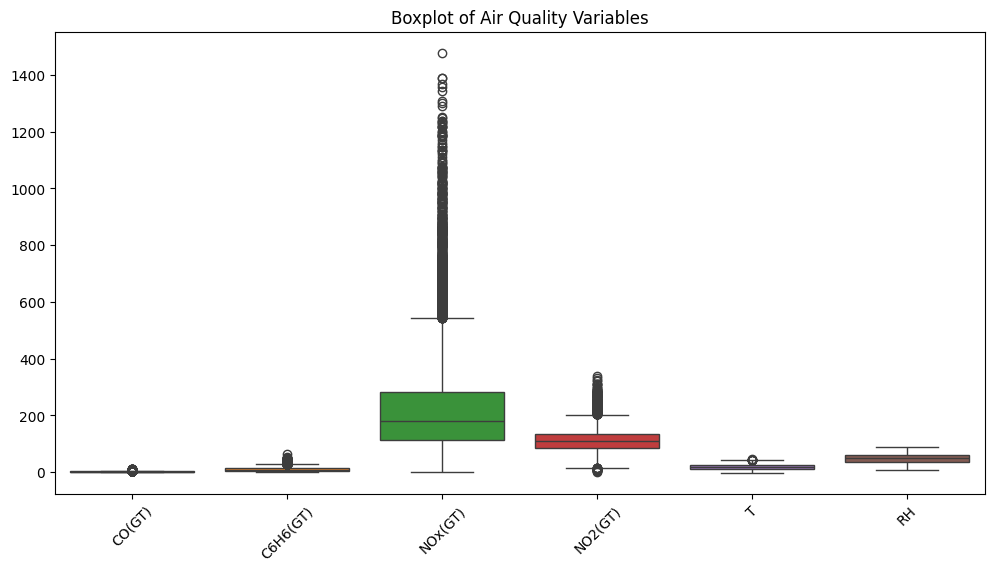

In [114]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[["CO(GT)","C6H6(GT)","NOx(GT)", "NO2(GT)","T","RH"]])
plt.xticks(rotation=45)
plt.title("Boxplot of Air Quality Variables")
plt.show()

NOx(GT) has very high values. The other features have lower values.


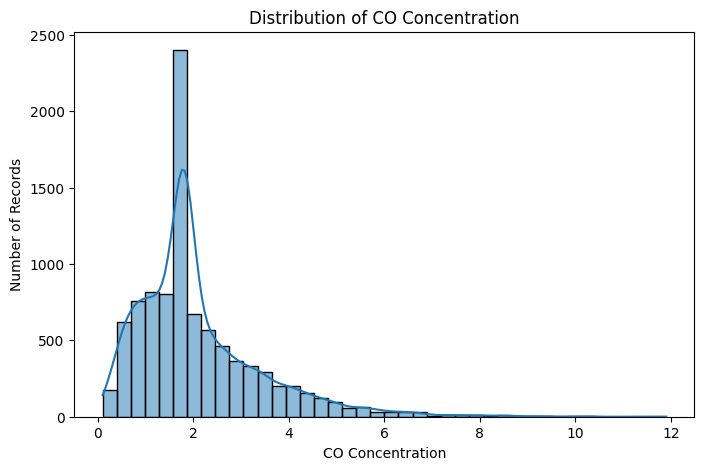

In [115]:
plt.figure(figsize=(8, 5))
sns.histplot(df["CO(GT)"], bins=40, kde=True)
plt.title("Distribution of CO Concentration")
plt.xlabel("CO Concentration")
plt.ylabel("Number of Records")
plt.show()

Most CO values are low, but some are high. The value 1.8 may be missing data.


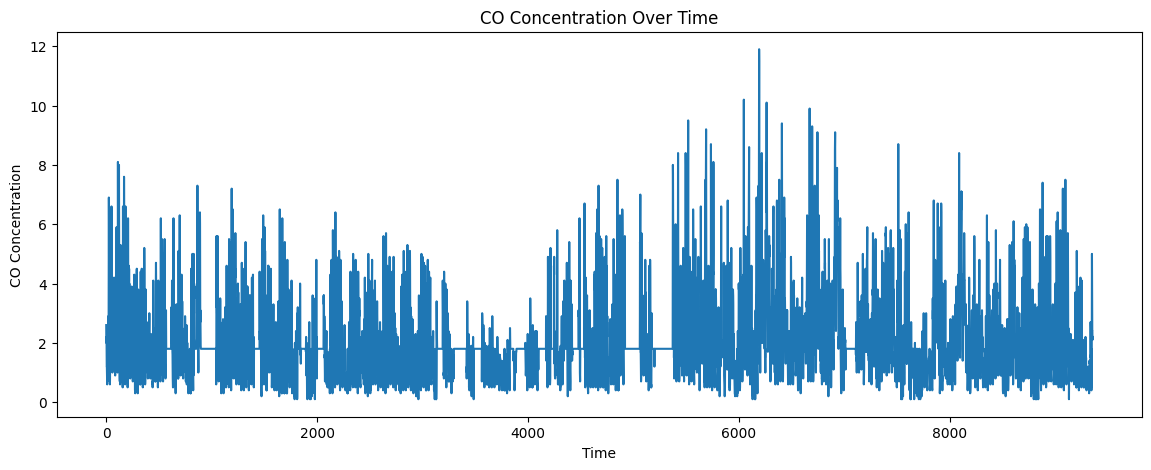

In [116]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["CO(GT)"])
plt.title("CO Concentration Over Time")
plt.xlabel("Time")
plt.ylabel("CO Concentration")
plt.show()

CO levels go up and down. Most values are between 0 and 6. Some values are higher.


In [117]:
corr_columns = [
    "CO(GT)",
    "PT08.S1(CO)",
    "NMHC(GT)",
    "C6H6(GT)",
    "PT08.S2(NMHC)",
    "NOx(GT)",
    "PT08.S3(NOx)",
    "NO2(GT)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH"
]
corr_columns

['CO(GT)',
 'PT08.S1(CO)',
 'NMHC(GT)',
 'C6H6(GT)',
 'PT08.S2(NMHC)',
 'NOx(GT)',
 'PT08.S3(NOx)',
 'NO2(GT)',
 'PT08.S4(NO2)',
 'PT08.S5(O3)',
 'T',
 'RH',
 'AH']

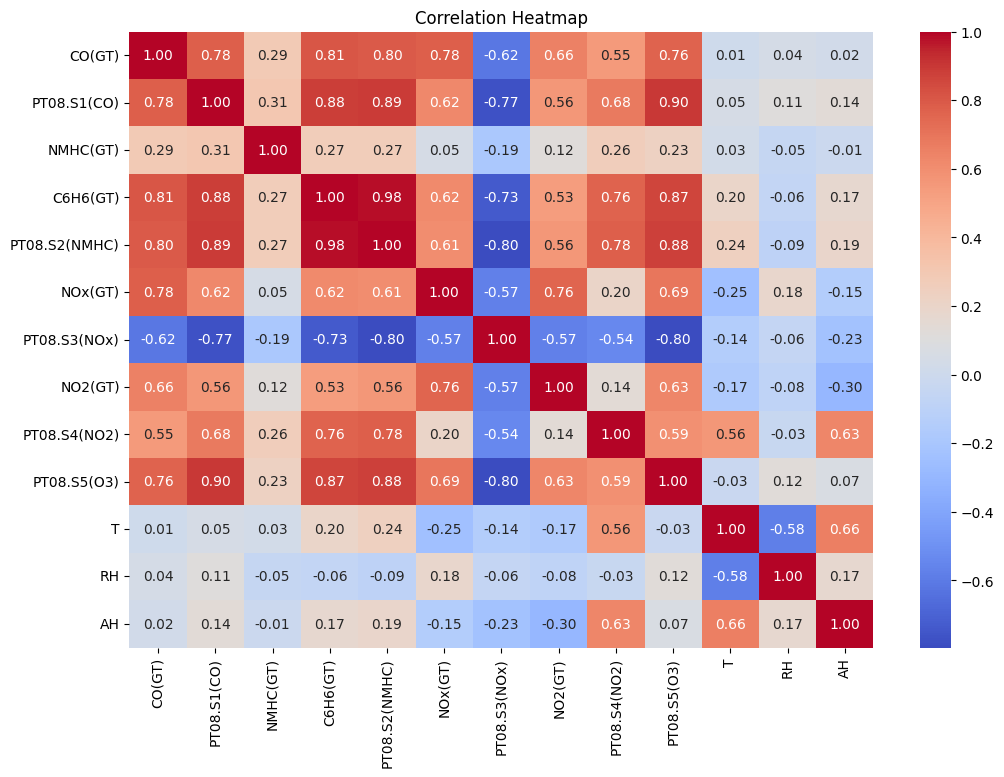

In [118]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[corr_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

CO is related to other pollutants. Temperature and humidity have little effect on CO.


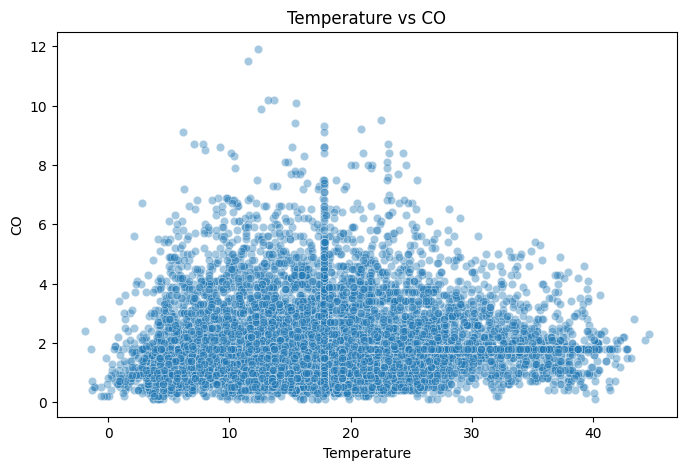

In [119]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["T"],y=df["CO(GT)"],alpha=0.4)
plt.title("Temperature vs CO")
plt.xlabel("Temperature")
plt.ylabel("CO")
plt.show()

Temperature does not have a strong effect on CO. CO levels are generally higher at cooler temperatures.


In [137]:
target = "CO(GT)"

features = [
    "PT08.S1(CO)",
    "NMHC(GT)",
    "C6H6(GT)",
    "PT08.S2(NMHC)",
    "NOx(GT)",
    "PT08.S3(NOx)",
    "NO2(GT)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T",
    "RH",
    "AH",
    "year",
    "month",
    "day",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_rush_hour"
]

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9357, 19)
y shape: (9357,)


In [122]:
n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:validation_end]
y_val = y.iloc[train_end:validation_end]

X_test = X.iloc[validation_end:]
y_test = y.iloc[validation_end:]

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

Training set: (6549, 19)
Validation set: (1404, 19)
Testing set: (1373, 19)


In [123]:
from sklearn.impute import SimpleImputer

linear_model = Pipeline([
    ("imputer", SimpleImputer(missing_values=np.nan, strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['year' 'month' 'day' 'hour' 'day_of_week']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['year' 'month' 'day' 'hour' 'day_of_week']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


This code fills missing values, scales the data, and trains a Linear Regression model to predict CO.


In [124]:
rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


This code trains a Random Forest model with 200 trees to predict CO. It can learn complex patternsand needs data with no missing values.


In [125]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [126]:
gb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['year' 'month' 'day' 'hour' 'day_of_week']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['year' 'month' 'day' 'hour' 'day_of_week']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


This code fills missing values, scales the data, and trains 200 trees. Each tree learns from the mistakes of the previous one to improve accuracy.


In [127]:
linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['year' 'month' 'day' 'hour' 'day_of_week']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['year' 'month' 'day' 'hour' 'day_of_week']. At least one non-missing value

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=200,
                                           random_state=42))])

In [128]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_pred
    )
)

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.346911,0.519227,0.842494
1,Random Forest,0.456892,0.674204,0.734439
2,Gradient Boosting,0.480742,0.713115,0.702902


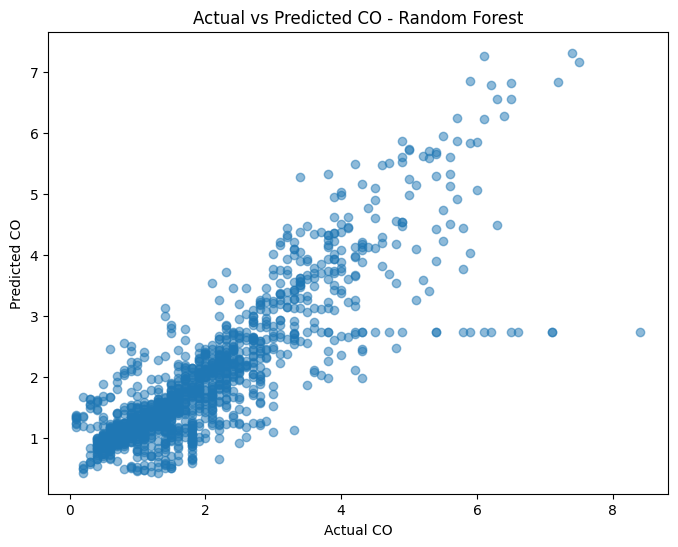

In [129]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test,rf_pred,alpha=0.5)
plt.xlabel("Actual CO")
plt.ylabel("Predicted CO")
plt.title("Actual vs Predicted CO - Random Forest")
plt.show()

The model works well for low CO values but is less accurate for high CO values.


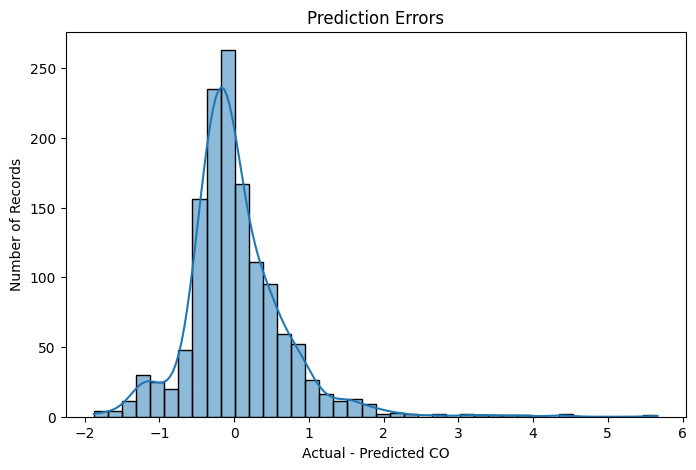

In [130]:
errors = y_test - rf_pred
plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=40, kde=True)
plt.title("Prediction Errors")
plt.xlabel("Actual - Predicted CO")
plt.ylabel("Number of Records")
plt.show()

Most predictions are close to the actual values. Sometimes, the model predicts a lower CO value than the real value.


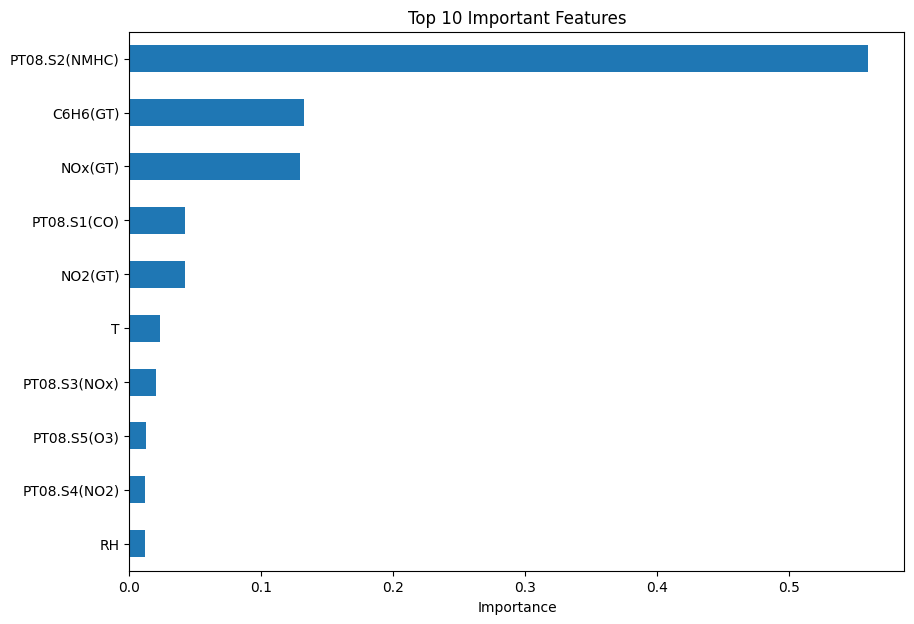

In [131]:
rf = rf_model.named_steps["model"]
importance = pd.Series(rf.feature_importances_,index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 7))
importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

The model mainly uses PT08.S2(NMHC)to make predictions. C6H6(GT) and NOx(GT) are also useful, while temperature and humidityhave less effect.


In [132]:
joblib.dump(rf_model, "air_quality_model.pkl")
joblib.dump(features, "air_quality_features.pkl")

print("Model saved successfully!")

Model saved successfully!


In [133]:
loaded_model = joblib.load("air_quality_model.pkl")
loaded_features = joblib.load("air_quality_features.pkl")
print("Model loaded successfully!")

Model loaded successfully!


In [134]:
sample = X_test.iloc[[0]]
prediction = loaded_model.predict(sample)
print("Predicted CO:", prediction[0])
print("Actual CO:", y_test.iloc[0])

Predicted CO: 1.1555000000000022
Actual CO: 0.8
